In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import yfinance as yf
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:
chile_tickers = [
    "ABC.SN", "AGUAS-A.SN", "ALMENDRAL.SN", "ANTARCHILE.SN", "AZUL-AZUL.SN",
    "BANVIDA.SN", "BCI.SN", "BESALCO.SN", "BINT.SN", "BLUMAR.SN", "BSANTANDER.SN",
    "CALICHERAA.SN", "CAMANCHACA.SN", "CAMPOS.SN", "CAP.SN", "CAROZZI.SN", "CCU.SN", "CEMENTOS.SN",
    "CENCOMALLS.SN", "CENCOSUD.SN", "CGE.SN", "CGET.SN", "CHILE.SN", "CIC.SN", "CINTAC.SN",
    "CMPC.SN", "COLBUN.SN", "COLO-COLO.SN", "CONCHATORO.SN", "COPEC.SN", "COPEVAL.SN", "CRISTALES.SN",
    "CRUZADOS.SN", "CTC.SN", "CUPRUM.SN", "DUNCANFOX.SN", "ECL.SN", "EISA.SN", "ELECMETAL.SN",
    "EMILIANA.SN", "ENAEX.SN", "ENELAM.SN", "ENELCHILE.SN", "ENELDXCH.SN", "ENELGXCH.SN", "ENJOY.SN",
    "ENLASA.SN", "ENTEL.SN", "ESVAL-C.SN", "FALABELLA.SN", "FORUS.SN", "FOSFOROS.SN", "FROWARD.SN",
    "GASCO.SN", "HABITAT.SN", "HIPERMARC.SN", "HITES.SN", "IAM.SN",
    "IANSA.SN", "ILC.SN", "INDISA.SN", "INFODEMA.SN", "INGEVEC.SN", "INVERCAP.SN", "INVERNOVA.SN",
    "ITAUCL.SN", "LAS-CONDES.SN", "LIPIGAS.SN", "MALLPLAZA.SN", "MANQUEHUE.SN", "MARINSA.SN",
    "MASISA.SN", "MELON.SN", "MINERA.SN", "MOLLER.SN", "MOLYMET.SN", "MULTI-X.SN", "NAVARINO.SN",
    "NAVIERA.SN", "NIBSA.SN", "NITRATOS.SN", "NORTEGRAN.SN", "NTGCLGAS.SN", "NUAM.SN", "NUTRAVALOR.SN",
    "ORO-BLANCO.SN", "OXIQUIM.SN", "PARAUCO.SN", "PASUR.SN", "PAZ.SN", "PEHUENCHE.SN", "PLANVITAL.SN",
    "POLO.SN", "POLPAICO.SN", "POTASIOS-A.SN", "PROVIDA.SN", "QUINENCO.SN", "RIPLEY.SN", "SALFACORP.SN",
    "SALMOCAM.SN", "SCHWAGER.SN", "SCOTIABKCL.SN", "SIEMEL.SN", "SK.SN", "SMSAAM.SN", "SMU.SN",
    "SOCOVESA.SN", "SONDA.SN", "SOQUICOM.SN", "SQM", "TRICAHUE.SN", "TRICOT.SN", "VAPORES.SN",
    "VENTANAS.SN", "VOLCAN.SN", "VSPT.SN", "WATTS.SN", "ZOFRI.SN", "CLP=X", # "^IPSA" , "BICE.SN"
]

In [3]:
""" data_20y = yf.download(
    tickers=" ".join(chile_tickers),
    period="20y",  # Periodo de 20 años
    interval="1d", # Intervalo diario (el más granular para este periodo)
    group_by='ticker' # Organiza los datos por ticker en el DataFrame
)

data_20y.columns = data_20y.columns.map('_'.join)

data_20y.to_csv(os.path.join("..", "data", "chile-stocks-raw.csv")) """

' data_20y = yf.download(\n    tickers=" ".join(chile_tickers),\n    period="20y",  # Periodo de 20 años\n    interval="1d", # Intervalo diario (el más granular para este periodo)\n    group_by=\'ticker\' # Organiza los datos por ticker en el DataFrame\n)\n\ndata_20y.columns = data_20y.columns.map(\'_\'.join)\n\ndata_20y.to_csv(os.path.join("..", "data", "chile-stocks-raw.csv")) '

In [25]:
data_20y = pd.read_csv(os.path.join("..", "data", "chile-stocks-raw.csv"))
data_20y["Date"] = pd.to_datetime(data_20y["Date"])
data_20y = data_20y.set_index("Date")
data_20y = data_20y[data_20y.any().index]

data_20y = data_20y[ list(filter(lambda x: "Adj" not in x, data_20y.columns)) ]

# Data cleaning

## Azul azul

<Axes: xlabel='Date'>

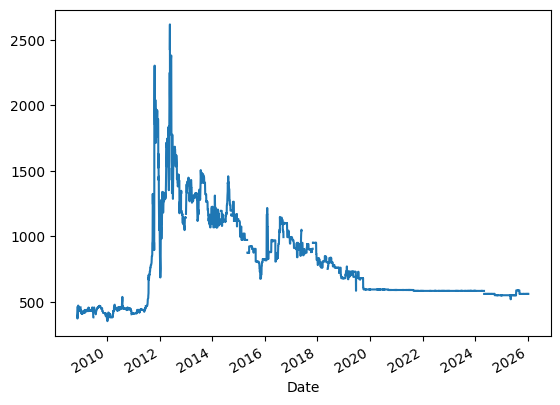

In [26]:
data_20y["AZUL-AZUL.SN_Close"][data_20y["AZUL-AZUL.SN_Close"] < 1] = None
#data_20y["AZUL-AZUL.SN_Close"] = data_20y["AZUL-AZUL.SN_Close"].ffill()
data_20y["AZUL-AZUL.SN_Close"].plot()

## Camanchaca

<Axes: xlabel='Date'>

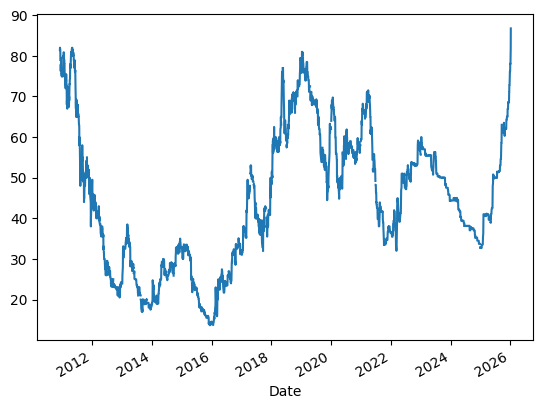

In [27]:
data_20y.loc[ data_20y["CAMANCHACA.SN_Close"] > 1000, "CAMANCHACA.SN_Close"] = None
data_20y["CAMANCHACA.SN_Close"].plot()

## BSantander

<Axes: xlabel='Date'>

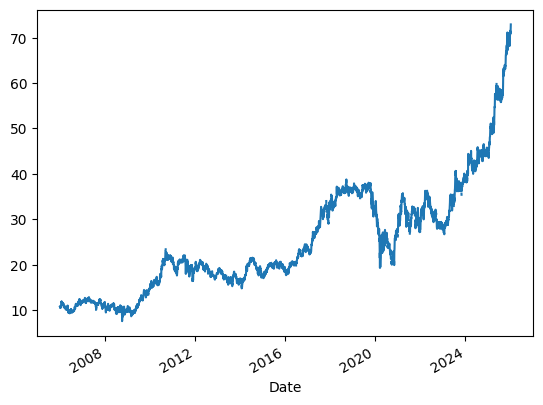

In [28]:
data_20y.loc[ data_20y["BSANTANDER.SN_Close"] > 250, "BSANTANDER.SN_Close"] = None
data_20y["BSANTANDER.SN_Close"].plot()

## ENJOY

<Axes: xlabel='Date'>

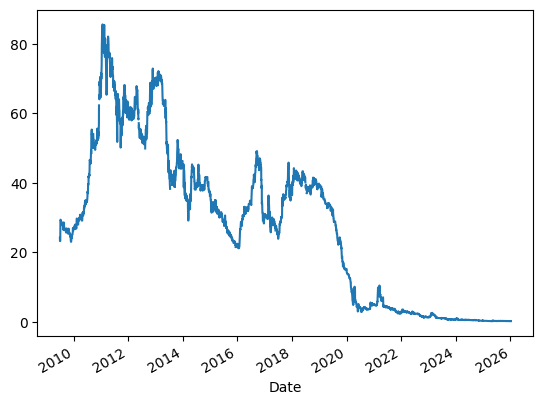

In [29]:
data_20y.loc[ ("2009-06-01" < data_20y.index) & ("2009-08-01" > data_20y.index) & (data_20y["ENJOY.SN_Close"] < 2), "ENJOY.SN_Close"] = None 
data_20y["ENJOY.SN_Close"].plot()

## ENLASA

<Axes: xlabel='Date'>

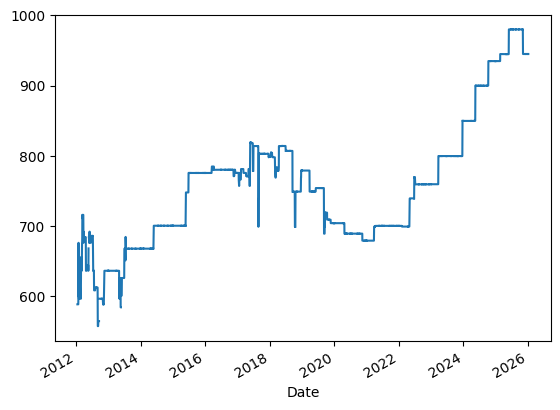

In [30]:
data_20y.loc[ ("2011-12-29" < data_20y.index) & ("2012-01-13" > data_20y.index), "ENLASA.SN_Close"] = None 
data_20y["ENLASA.SN_Close"].plot()

## QUINENCO

<Axes: xlabel='Date'>

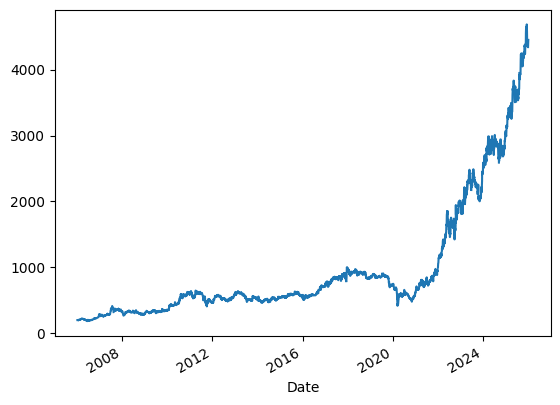

In [31]:
data_20y.loc[ data_20y["QUINENCO.SN_Close"] > 10_000, "QUINENCO.SN_Close"] = None 
data_20y["QUINENCO.SN_Close"].plot()

## ZOFRI 

<Axes: xlabel='Date'>

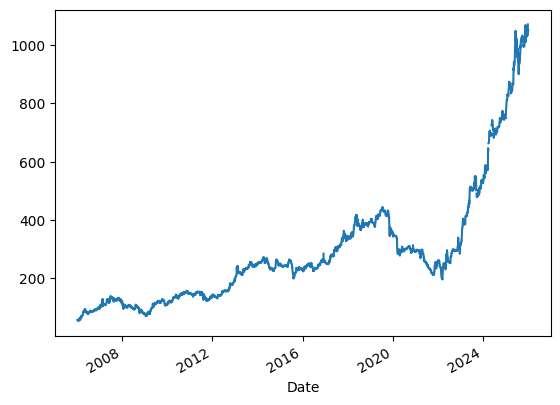

In [32]:
data_20y.loc[ (data_20y.index > "2011-06-01") & (data_20y.index < "2012") & ( data_20y["ZOFRI.SN_Close"] < 100) ,"ZOFRI.SN_Close"] = None 
data_20y["ZOFRI.SN_Close"].plot()

## NUAM 

<Axes: xlabel='Date'>

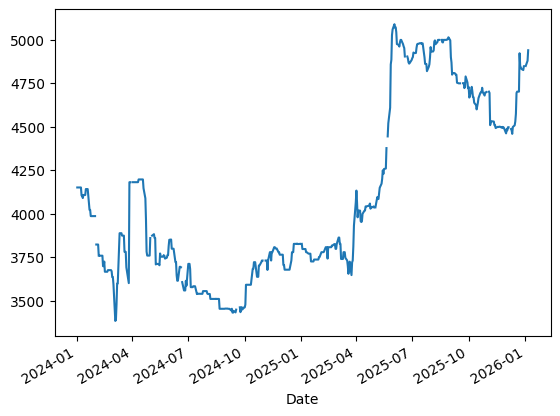

In [33]:
data_20y.loc[ (data_20y.index > "2023-10") & (data_20y.index < "2024-01")  ,"NUAM.SN_Close"] = None 
data_20y["NUAM.SN_Close"].plot()

## CLP USD

<Axes: xlabel='Date'>

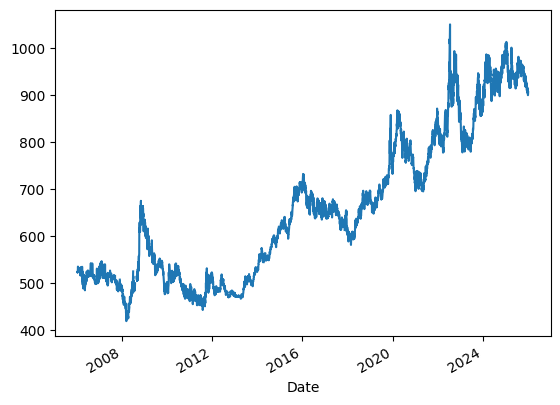

In [34]:
data_20y.loc[ data_20y["CLP=X_Close"] < 200 ,"CLP=X_Close"] = None 
data_20y["CLP=X_Close"].plot()

## HITES

<Axes: xlabel='Date'>

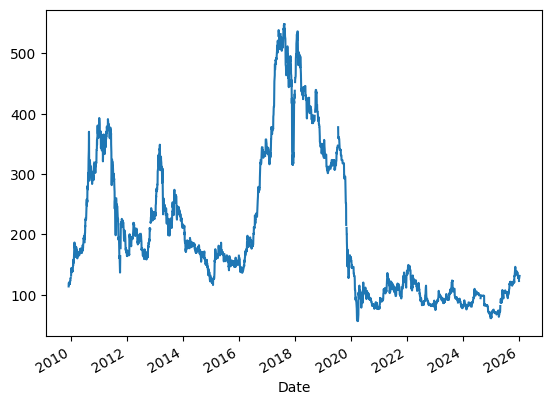

In [35]:
data_20y.loc[ (data_20y.index > "2009-11-01") & (data_20y.index < "2010-01-30") & (data_20y["HITES.SN_Close"] < 100),"HITES.SN_Close"] = None
data_20y["HITES.SN_Close"].plot()

## Fill Nan data with forward fill

In [36]:
data_20y = data_20y.ffill()

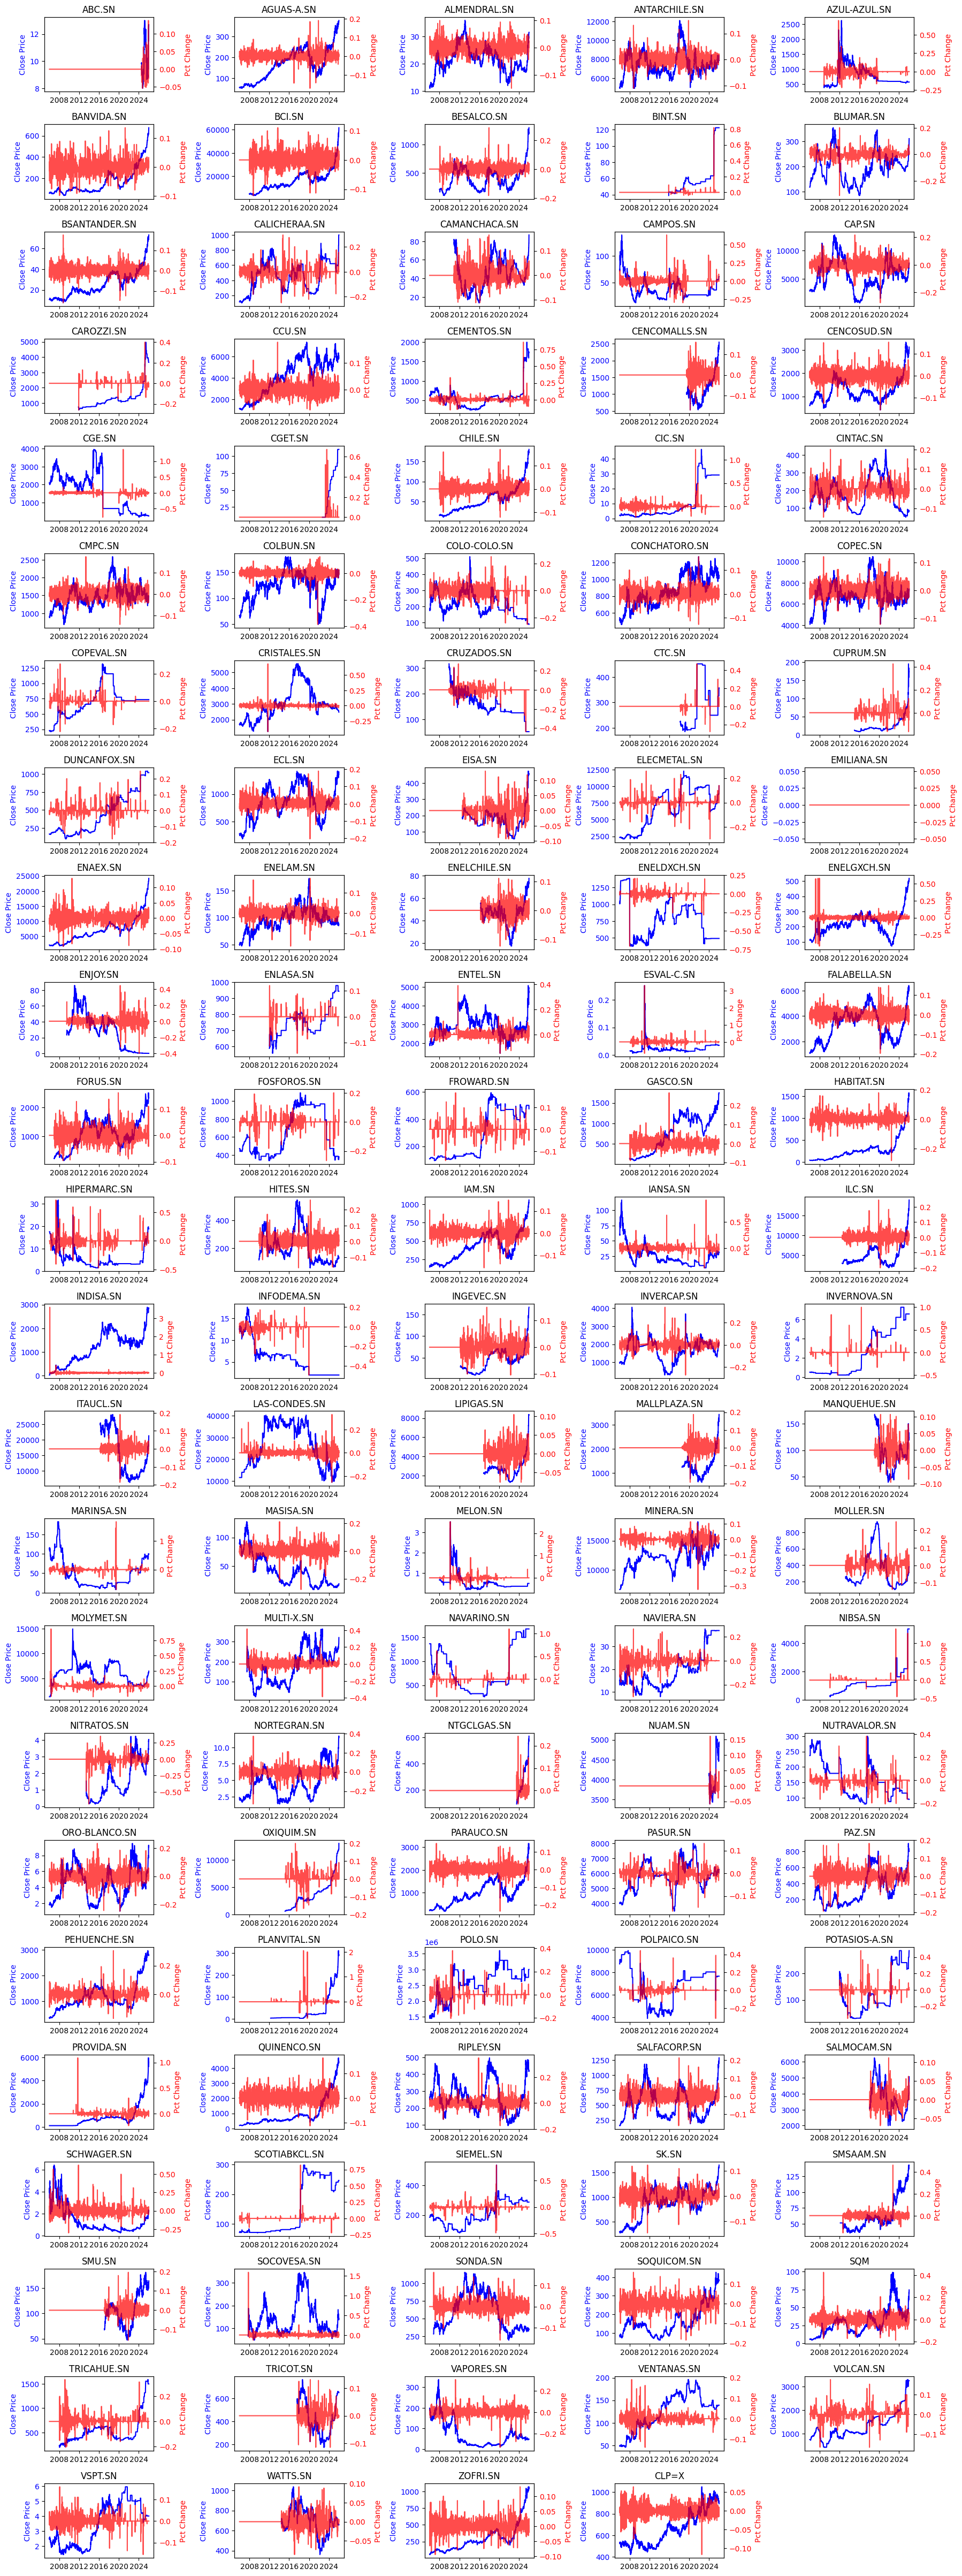

In [37]:
plt.figure(figsize = (18, 50))

for i, ticker in enumerate(chile_tickers):
    
    ax = plt.subplot(25, 5, i + 1)
    plt.title(ticker)
    
    # Plot closing prices on primary y-axis
    ax.plot(data_20y[ticker + "_Close"], color='blue', label='Close')
    ax.set_ylabel('Close Price', color='blue')
    ax.tick_params(axis='y', labelcolor='blue')
    
    # Create secondary y-axis for percentage changes
    ax2 = ax.twinx()
    pct_change = data_20y[ticker + "_Close"].pct_change().fillna(0)
    ax2.plot(pct_change, color='red', label='Pct Change', alpha=0.7)
    ax2.set_ylabel('Pct Change', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()

In [39]:
data_20y_multi = data_20y.copy()

data_20y_multi.columns = pd.MultiIndex.from_tuples(
    [col.rsplit('_', 1) for col in data_20y.columns],
    names=['Ticker', 'Price']
)

# Ticker in index (reshape to long)
# Requires MultiIndex columns with levels ['Ticker', 'Price']
data_20y_idx = data_20y_multi.stack(level='Ticker')
# Name the index levels for clarity
data_20y_idx.index.set_names(['Date', 'Ticker'], inplace=True)
# Keep things nicely ordered
data_20y_idx = data_20y_idx.sort_index()

# Preview
data_20y_idx.head()

Price                            Open         High          Low        Close  \
Date       Ticker                                                              
2006-01-06 AGUAS-A.SN       54.964417    56.165825    54.964417    56.165825   
           ALMENDRAL.SN     11.554567    11.652487    11.280391    11.476231   
           ANTARCHILE.SN  4916.056326  5000.815918  4916.056326  5000.815918   
           BANVIDA.SN       60.147400    60.147400    60.147400    60.147400   
           BLUMAR.SN       116.557767   116.984718   116.557767   116.984718   

Price                         Volume  
Date       Ticker                     
2006-01-06 AGUAS-A.SN        55200.0  
           ALMENDRAL.SN   29352789.0  
           ANTARCHILE.SN    104100.0  
           BANVIDA.SN            0.0  
           BLUMAR.SN         28700.0

In [40]:
data_20y_idx.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 528966 entries, (Timestamp('2006-01-06 00:00:00'), 'AGUAS-A.SN') to (Timestamp('2026-01-07 00:00:00'), 'ZOFRI.SN')
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Open    528966 non-null  float64
 1   High    528966 non-null  float64
 2   Low     528966 non-null  float64
 3   Close   528857 non-null  float64
 4   Volume  528966 non-null  float64
dtypes: float64(5)
memory usage: 21.9+ MB


In [41]:
with pd.HDFStore(os.path.join("..", "data", "assets.h5")) as store:
    store.put('stocks/chile', data_20y_idx)

In [17]:
data_20y = data_20y[list(filter( lambda x: "Close" in x, data_20y.columns))]

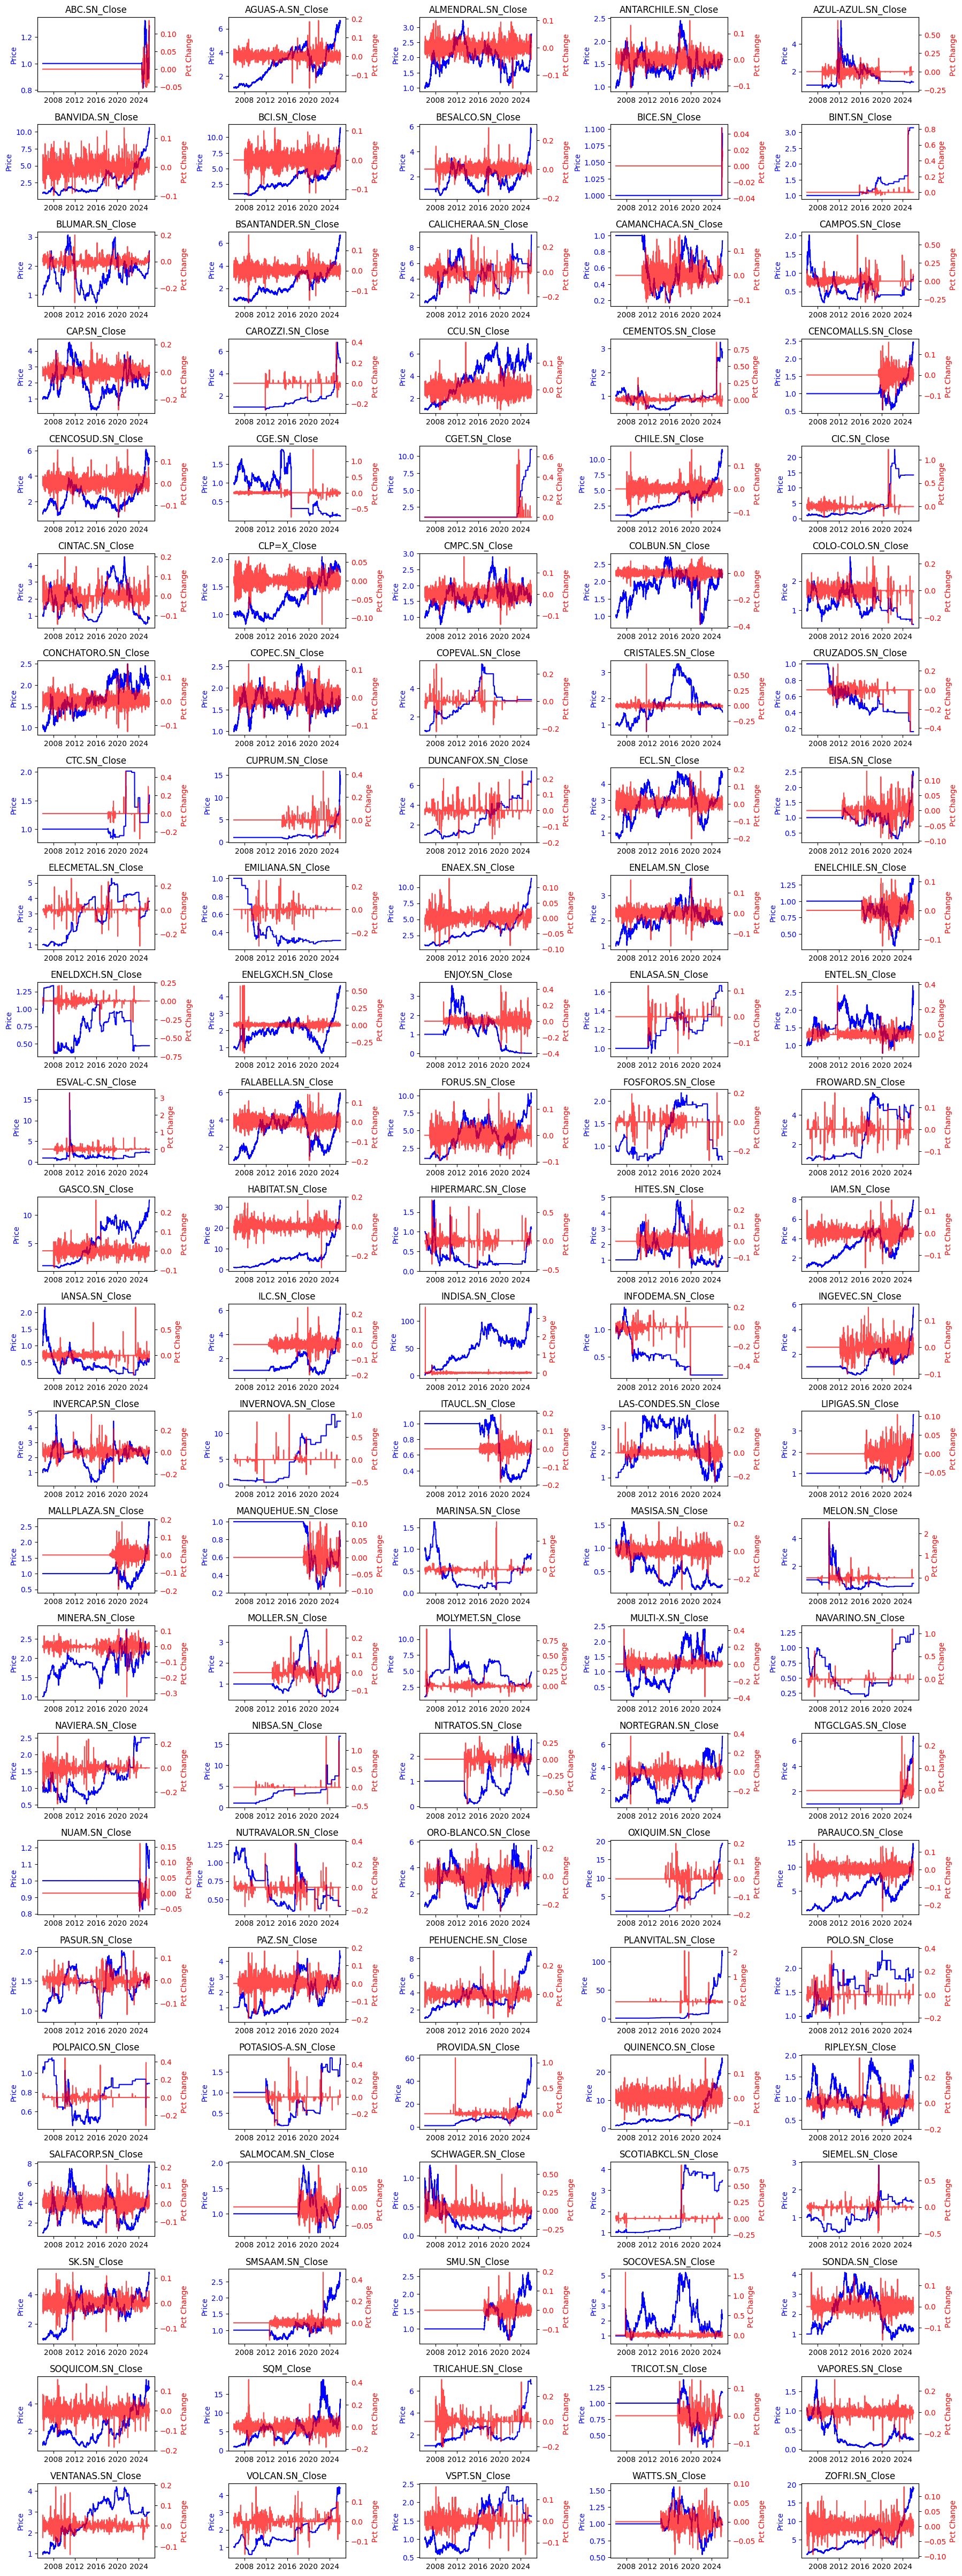

In [18]:
plt.figure(figsize = (18, 50))

for i, column in enumerate(data_20y.columns.sort_values()):
    
    ax = plt.subplot(25, 5, i + 1)
    plt.title(column)
    
    diff = data_20y[column].pct_change().fillna(0)
    normalized = (1 + diff).cumprod()
    
    # Plot closing prices on primary y-axis
    ax.plot(normalized, color='blue', label='Close')
    ax.set_ylabel('Price', color='blue')
    ax.tick_params(axis='y', labelcolor='blue')
    
    # Create secondary y-axis for percentage changes
    ax2 = ax.twinx()
    ax2.plot(diff, color='red', label='Pct Change', alpha=0.7)
    ax2.set_ylabel('Pct Change', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()

In [28]:
data_20y.columns = data_20y.columns.str.replace("_Close", "")

In [29]:
data_20y.head(1)

,NAVARINO.SN,VOLCAN.SN,ENAEX.SN,CAMANCHACA.SN,CIC.SN,MOLYMET.SN,SMSAAM.SN,BSANTANDER.SN,PAZ.SN,CGET.SN,...,SALFACORP.SN,CTC.SN,COPEC.SN,FOSFOROS.SN,CCU.SN,SOCOVESA.SN,CONCHATORO.SN,CINTAC.SN,ZOFRI.SN,PEHUENCHE.SN
Date,,,,,,,,,,,,,,,,,,,,,
2005-12-29,1374.166138,733.996094,2065.921875,NaN,2.048007,1287.379272,NaN,10.618567,NaN,NaN,...,157.389816,NaN,4091.289062,499.554626,1042.445435,NaN,509.326416,95.958549,55.236153,333.404236


In [30]:
data_20y.to_csv(os.path.join("..", "data", "chile-stocks-close.csv"))

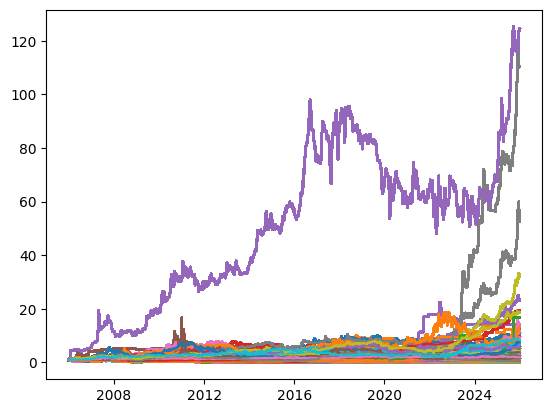

In [19]:
normalized = (1 + data_20y.pct_change().fillna(0)).cumprod()

for name in data_20y.columns:
    plt.plot(normalized)
    
plt.show()

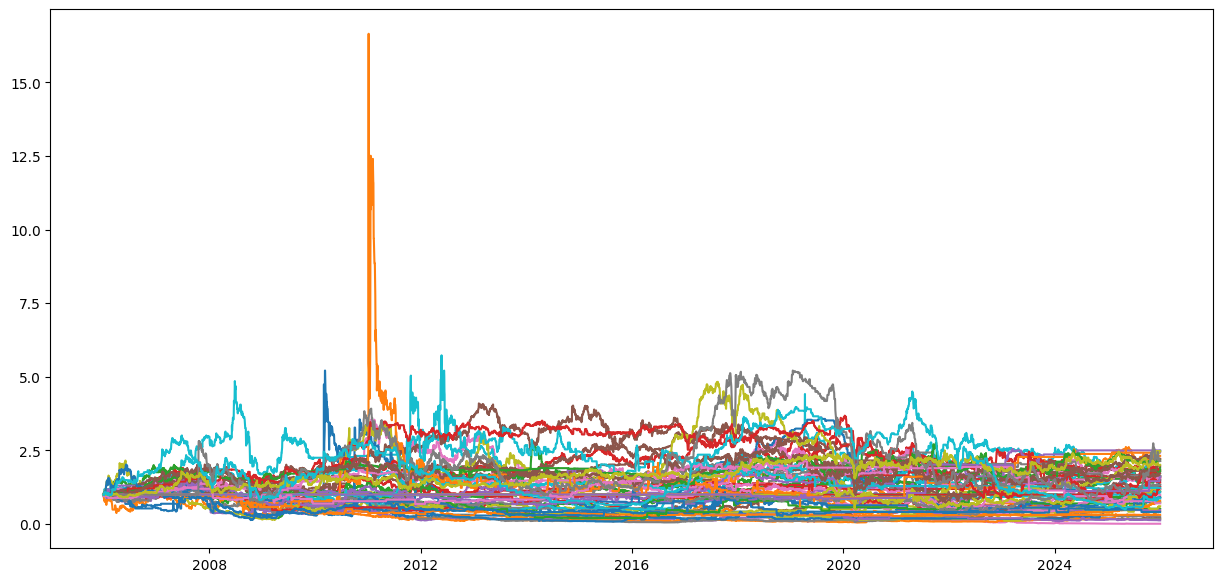

In [20]:
plt.figure(figsize = (15, 7))
plt.plot(normalized.loc[:, normalized.iloc[-1, :].quantile(0.5) > normalized.iloc[-1, :]])
plt.show()

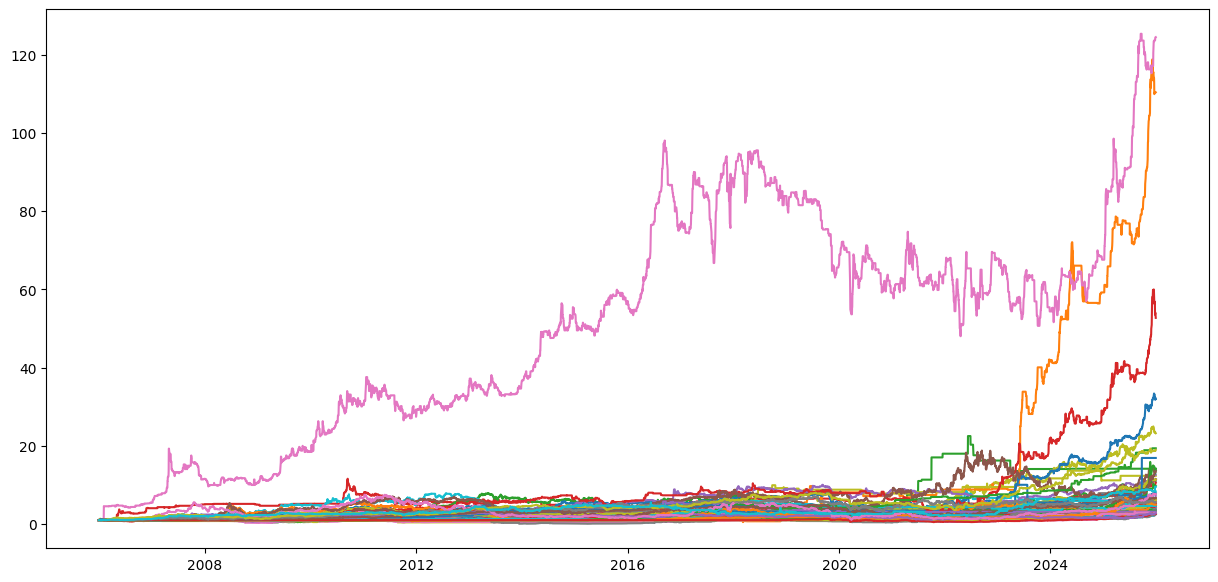

In [21]:
plt.figure(figsize = (15, 7))
plt.plot(normalized.loc[:, normalized.iloc[-1, :].quantile(0.5) < normalized.iloc[-1, :]])
plt.show()

In [22]:
normalized

,NAVARINO.SN_Close,VOLCAN.SN_Close,ENAEX.SN_Close,CAMANCHACA.SN_Close,CIC.SN_Close,MOLYMET.SN_Close,SMSAAM.SN_Close,BSANTANDER.SN_Close,PAZ.SN_Close,CGET.SN_Close,...,SALFACORP.SN_Close,CTC.SN_Close,COPEC.SN_Close,FOSFOROS.SN_Close,CCU.SN_Close,SOCOVESA.SN_Close,CONCHATORO.SN_Close,CINTAC.SN_Close,ZOFRI.SN_Close,PEHUENCHE.SN_Close
Date,,,,,,,,,,,,,,,,,,,,,
2005-12-29,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2005-12-30,1.000000,1.022223,1.000000,1.000000,0.963462,1.000000,1.000000,0.968610,1.000000,1.000000,...,1.027451,1.000000,1.000090,0.999937,1.021611,1.000000,1.000000,1.013514,0.975609,1.060345
2006-01-02,1.000000,1.022223,1.000000,1.000000,0.961538,1.000000,1.000000,0.968610,1.000000,1.000000,...,1.019608,1.000000,0.989496,0.999937,0.999748,1.000000,0.999960,1.013514,0.951220,1.060345
2006-01-03,0.994530,1.022223,1.000000,1.000000,1.008654,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.019608,1.000000,0.998512,0.943990,1.013661,1.000000,1.015867,1.010135,0.951220,1.060345
2006-01-04,0.994530,1.009524,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.019608,1.000000,1.025560,0.943990,1.033536,1.000000,1.033085,1.010135,1.010732,1.060345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-22,1.220231,4.427816,11.252120,0.894303,14.160111,4.738308,2.745191,6.658149,4.316848,10.996773,...,7.655515,1.451805,1.676733,0.700624,5.559044,2.216963,1.985171,0.874440,18.719624,8.393715
2025-12-23,1.220231,4.427816,11.252120,0.909044,14.160111,4.738308,2.745191,6.606353,4.294796,10.996773,...,7.675846,1.451805,1.683088,0.700624,5.650080,2.218917,1.983011,0.874440,18.721434,8.367920
2025-12-24,1.220231,4.427816,11.252120,0.909044,14.160111,4.738308,2.745191,6.631780,4.294796,10.996773,...,7.656150,1.451805,1.681622,0.700624,5.572474,2.194560,1.983011,0.874440,18.828248,8.367920


# Market meta data